# Phase 6 — Cluster Analysis and Visualization

We look at what connects tickets inside the 48 clusters found in Phase 5 (SBERT + HDBSCAN, `min_cluster_size=50`).

In [1]:
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_row
from preprocessing import substitute_template_vars, clean_description, drop_noise_columns, parse_dates
from feature_engineering import vectorize_tfidf, embed_sbert, reduce_umap
from clustering import run_hdbscan
from visualization import (plot_cluster_sizes, plot_umap_scatter, plot_cluster_category_distribution,
                            top_terms_per_cluster, plot_cluster_wordcloud,
                            find_representative_tickets, build_cluster_summary_table)

/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data + reproduce the winning clustering from Phase 5

In [2]:
df = load_row("../data/customer_support_tickets.csv")
df = substitute_template_vars(df)
df["Ticket Description"] = df["Ticket Description"].apply(clean_description)
df = drop_noise_columns(df)
df = parse_dates(df)

X_tfidf, tfidf_vectorizer = vectorize_tfidf(df["Ticket Description"])
X_sbert = embed_sbert(df["Ticket Description"])
X_sbert_50d = reduce_umap(X_sbert, n_components=50)
X_sbert_2d = reduce_umap(X_sbert, n_components=2)

labels, hdbscan_model = run_hdbscan(X_sbert_50d, min_cluster_size=50)
df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct = (labels == -1).mean() * 100
print(f"n_clusters={n_clusters} noise_pct={noise_pct:.1f}%")

/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


n_clusters=48 noise_pct=6.8%


## 2. Cluster sizes

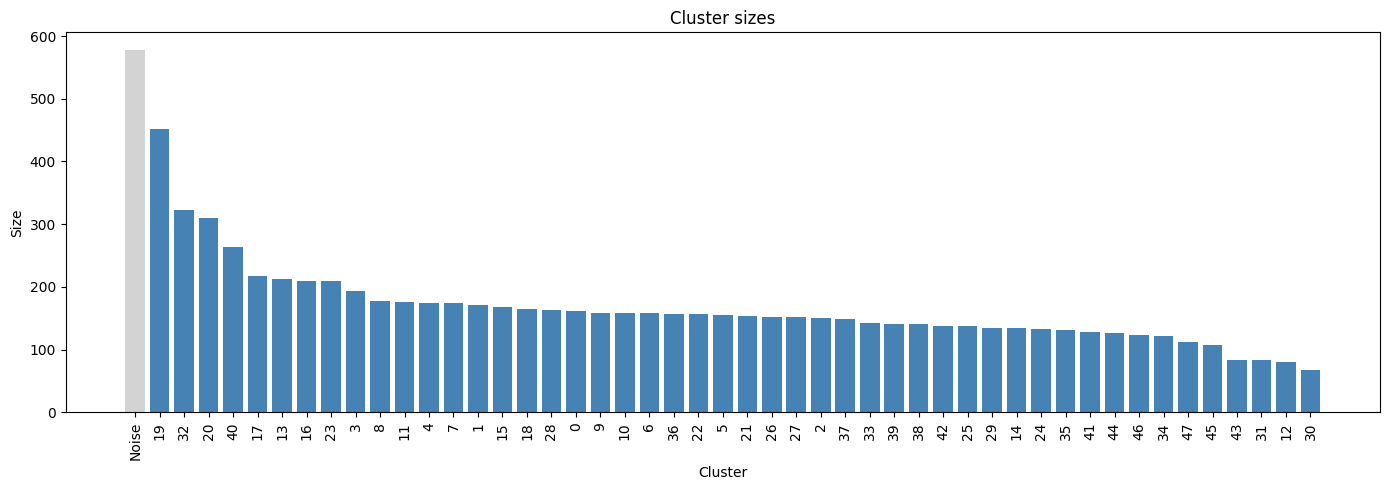

In [3]:
plot_cluster_sizes(labels, save_path="../reports/figures/cluster_sizes.png")

## 3. Per-cluster analysis — top 6 largest clusters

The full summary for all 48 clusters is in `reports/cluster_profiles.csv` (section 6). Here we look at the largest clusters by hand: a wordcloud + 2 representative tickets per cluster.

In [4]:
sizes = pd.Series(labels[labels != -1]).value_counts()
top_clusters = sizes.head(6).index.tolist()
print(sizes.head(6))

terms_by_cluster = top_terms_per_cluster(X_tfidf, labels, tfidf_vectorizer, top_n=10)
representatives = find_representative_tickets(X_sbert_50d, labels, df, n=2)

19    452
32    323
20    310
40    263
17    218
13    213
Name: count, dtype: int64


=== Cluster 19 (size=452) ===


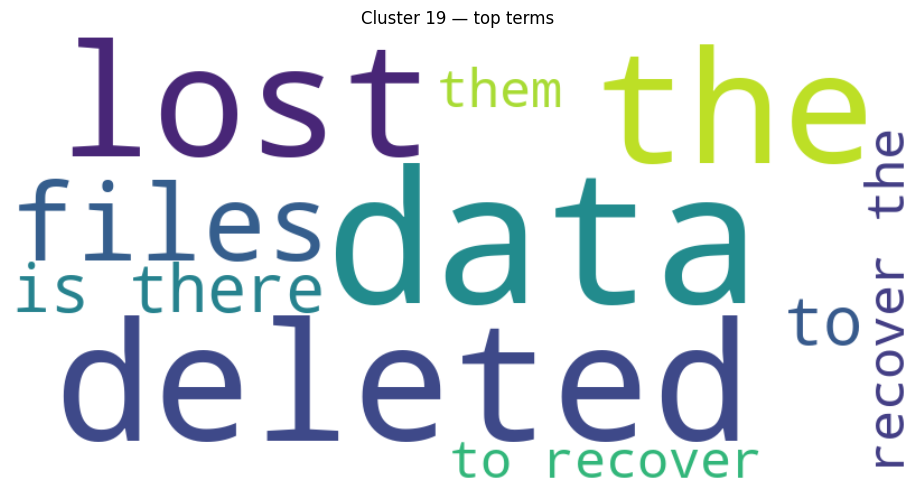

 Ticket ID Product Purchased     Ticket Type                                                                                                                                                                                                                                                                                                              Ticket Description
      7121  Microsoft Office  Refund request    I've encountered a data loss issue with my Microsoft Office. All the files and documents seem to have disappeared. Can you guide me on how to retrieve them? Also, are there any tools that will help prevent data loss? We I'm not sure if this issue is specific to my device or if others have reported similar problems.
      7359 Microsoft Surface Billing inquiry I've encountered a data loss issue with my Microsoft Surface. All the files and documents seem to have disappeared. Can you guide me on how to retrieve them? Thank you for reporting this issue. I would urge This problem start

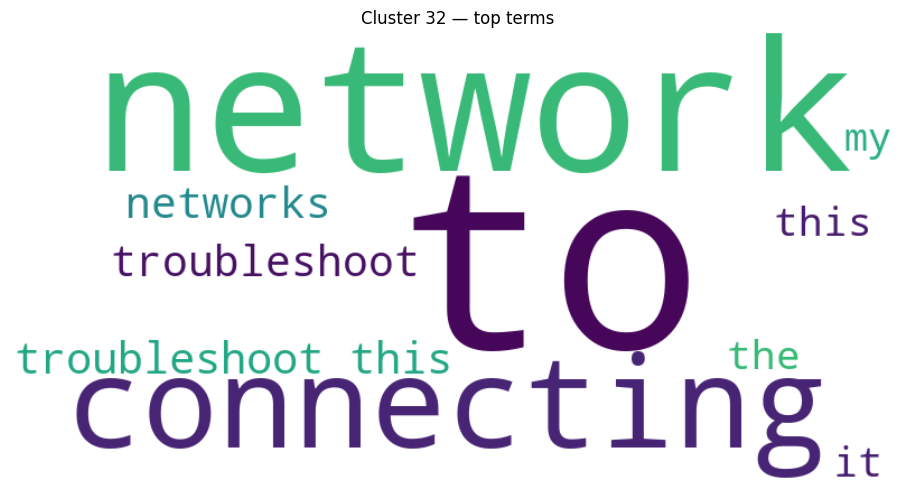

 Ticket ID Product Purchased    Ticket Type                                                                                                                                                                                                                                                                                                                                              Ticket Description
      3589          Dell XPS Refund request                              The Dell XPS is unable to establish a stable internet connection. It keeps disconnecting intermittently. How can I troubleshoot this network problem? Check the /proc/network settings on the node that is monitoring the firewall settings I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
      7536          Dell XPS Refund request The Dell XPS is unable to establish a stable internet connection. It keeps disconnecting intermittently. How can I troubleshoot this network problem? In the network

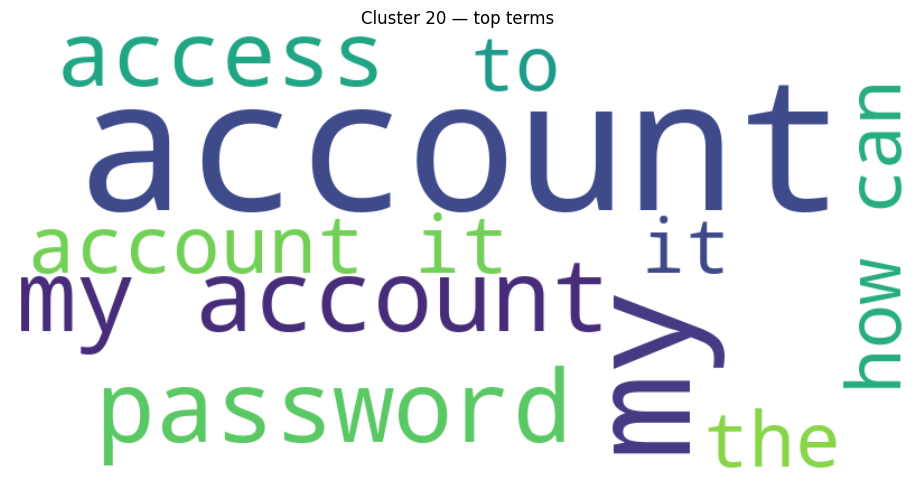

 Ticket ID Product Purchased          Ticket Type                                                                                                                                                                                                                                                                                 Ticket Description
      4696      Google Pixel Cancellation request I'm unable to access my Google Pixel account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account? Click here I've already contacted customer support multiple times, but the issue remains unresolved.
      7431      Google Pixel      Product inquiry      I'm unable to access my Google Pixel account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account? How can I've checked the device settings and made sure that everything is

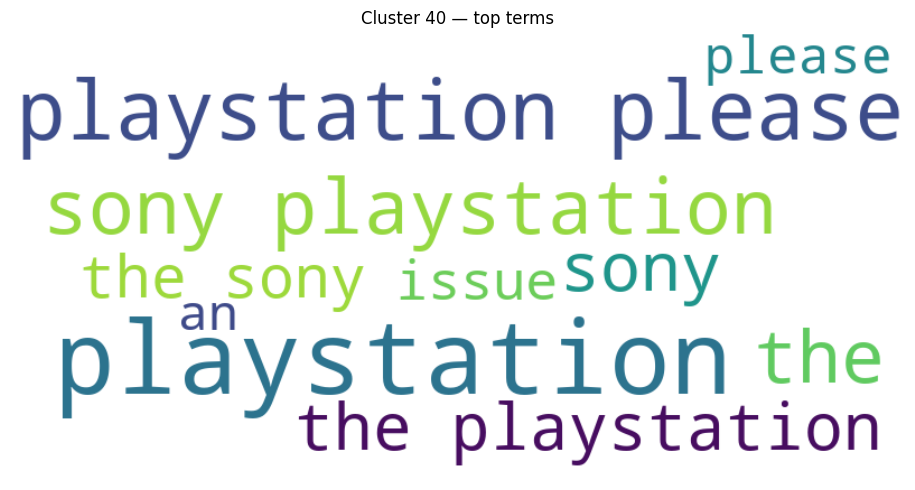

 Ticket ID Product Purchased     Ticket Type                                                                                                                                                                                                                                                                 Ticket Description
      2276       PlayStation Technical issue I'm having an issue with the PlayStation. Please assist. As for the case of your phone it's not going anywhere. I know it's there. I guess I'm not really going to be able to handle I'm worried that the issue might be hardware-related and might require repair or replacement.
       544       PlayStation  Refund request                                                            I'm having an issue with the PlayStation. Please assist. */ this.ProductVersion = { "name": "Graphene", "price": "$0.99", I'm worried that the issue might be hardware-related and might require repair or replacement.

=== Cluster 17 (size=218) ===


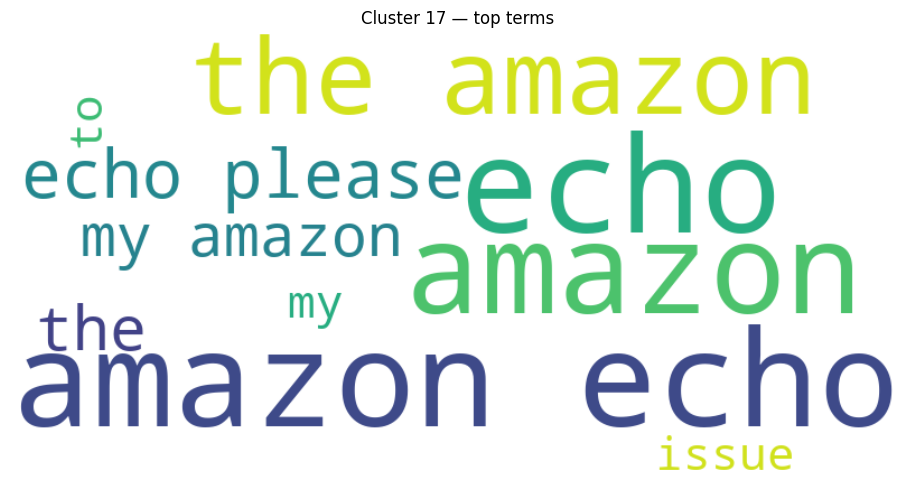

 Ticket ID Product Purchased          Ticket Type                                                                                                                                                                                                                                                     Ticket Description
      7140       Amazon Echo      Billing inquiry I'm having an issue with the Amazon Echo. Please assist. A message was posted by the administrator of this forum: " From: "James M" <james@gw2.com> To I've noticed that the issue occurs consistently when I use a specific feature or application on my Amazon Echo.
      5950       Amazon Echo Cancellation request                                                                           I'm having an issue with the Amazon Echo. Please assist. Please help. Please help! 1 of 1 I've followed online tutorials and community forums to troubleshoot the issue, but no luck so far.

=== Cluster 13 (size=213) ===


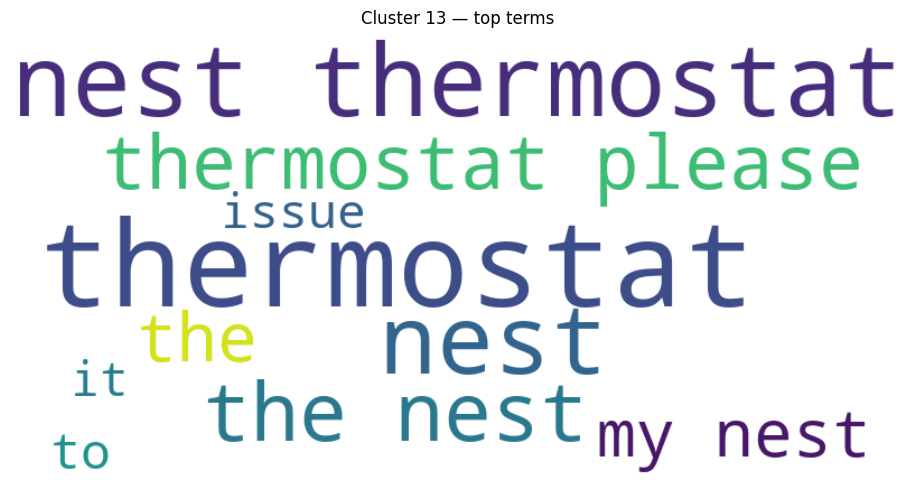

 Ticket ID Product Purchased     Ticket Type                                                                                                                                                                                                                                                                                        Ticket Description
      5418   Nest Thermostat  Refund request                       I'm having an issue with the Nest Thermostat. Please assist. If your device has a small size of screen, can I use the same screen size with 4dpix and is it in my current screen size or can I need assistance as soon as possible because it's affecting my work and productivity.
      3044   Nest Thermostat Product inquiry There seems to be a hardware problem with my Nest Thermostat. The screen is flickering, and I'm unable to use it. What should I do? Is there a way to get this fixed - is there a system to help me I'm concerned about the security of my Nest Thermostat and would like to 

In [5]:
for cid in top_clusters:
    size = (labels == cid).sum()
    print(f"=== Cluster {cid} (size={size}) ===")
    plot_cluster_wordcloud(cid, terms_by_cluster[cid])

    rep_idx = representatives[cid]
    print(df.iloc[rep_idx][["Ticket ID", "Product Purchased", "Ticket Type", "Ticket Description"]].to_string(index=False))
    print()

**Observation about the top 6 clusters** (checked directly — the real distribution of `Product Purchased` inside each cluster, not just the 2 examples shown above):

- **Clusters 19, 32, 20** — the product almost doesn't matter: the top product appears in only 4-6% of the cluster's tickets (with ~40 products, this is just random noise level). These clusters are held together **only by the template complaint phrase** ("data loss issue...", "unable to establish a stable connection...", "invalid credentials..."). The product is mentioned in the text, but it does not define the grouping.
- **Clusters 17, 13** — the opposite pattern: 93% of cluster 17's tickets are Amazon Echo, 93% of cluster 13's tickets are Nest Thermostat. Here the grouping mainly depends on the product.
- **Cluster 40 — a separate finding**: 100% of this cluster's tickets are `"Sony PlayStation"` (136) and `"PlayStation"` (127) **together**. These are two different string values in the `Product Purchased` column (checked across the whole dataset: 202 and 192 tickets respectively, 42 unique products total), but they are almost certainly the same real product with inconsistent labeling in the source data. SBERT correctly grouped them into one cluster, because it understands the meaning of the text instead of comparing category strings literally — a clear example of why we need semantic embeddings, not just one-hot encoding on `Product Purchased`.

This explains the Phase 5 finding: `Ticket Subject` (16 categories assigned randomly in this synthetic data) cannot match this structure, because the structure is based on a much more specific signal — the exact wording of the complaint and/or the product — not an abstract topic.

## 4. UMAP scatter: clusters vs Ticket Subject (side by side)

`plot_umap_scatter` is interactive (plotly) — when you run it in Jupyter, you can zoom in and click the legend. Here we show a static snapshot of both plots for comparison.

In [7]:
plot_umap_scatter(X_sbert_2d, labels, title="HDBSCAN clusters")

In [8]:
plot_umap_scatter(X_sbert_2d, df["Ticket Subject"].values, title="Ticket Subject (ground truth)")

The difference is easy to see: the first plot shows compact, clearly separated mini-clusters. The second plot (colored by `Ticket Subject`) shows the same points in the same positions, but the colors (categories) are mixed randomly inside each visual cluster, with no connection to its shape. This is the same finding as ARI≈0 in Phase 5 — now you can see it with your own eyes.

## 6. Cluster summary table

In [10]:
cluster_profiles = build_cluster_summary_table(df, labels, X_sbert_50d, tfidf_vectorizer, X_tfidf,
                                                 top_n_terms=10, n_representative=3)
cluster_profiles.to_csv("../reports/cluster_profiles.csv", index=False)
cluster_profiles.sort_values("size", ascending=False).head(10)

,cluster_id,size,pct_of_total,top_terms,top_ticket_type,top_ticket_subject,top_product,dominant_category_share,avg_satisfaction,representative_ticket_ids
0,-1,577,6.813083,NaN,Refund request,Battery life,Canon EOS,0.220104,2.994624,NaN
20,19,452,5.337112,data; deleted; the; lost; files; is there; to;...,Refund request,Battery life,Amazon Echo,0.230088,3.085106,7121; 7359; 2656
33,32,323,3.813910,to; network; connecting; troubleshoot this; tr...,Product inquiry,Product compatibility,Sony Xperia,0.219814,2.836538,3589; 7536; 6240
21,20,310,3.660409,account; my; my account; password; access; acc...,Product inquiry,Installation support,Microsoft Xbox Controller,0.209677,3.117021,4696; 7431; 7053
41,40,263,3.105443,playstation; playstation please; sony playstat...,Billing inquiry,Software bug,Sony PlayStation,0.220532,2.955556,2276; 544; 3368
18,17,218,2.574094,amazon echo; echo; amazon; the amazon; echo pl...,Technical issue,Delivery problem,Amazon Echo,0.229358,3.084507,7140; 5950; 5836
14,13,213,2.515055,thermostat; nest thermostat; nest; the nest; t...,Product inquiry,Payment issue,Nest Thermostat,0.230047,3.014493,5418; 3044; 6231
17,16,210,2.479632,google nest; nest; google; nest please; the go...,Billing inquiry,Delivery problem,Google Nest,0.252381,3.074627,1679; 7492; 5487
24,23,210,2.479632,fitbit charge; charge; fitbit; the fitbit; cha...,Technical issue,Delivery problem,Fitbit Charge,0.228571,2.838710,1036; 3263; 1689
4,3,194,2.290707,hue; hue lights; philips hue; philips; lights;...,Cancellation request,Delivery problem,Philips Hue Lights,0.226804,3.140351,1985; 1237; 3251


## 7. Narrative — conclusions

**What complaint/problem patterns we found:**

1. Unsupervised clustering (SBERT + HDBSCAN) finds a **real, dense structure** in the description texts — 48 clusters with silhouette ≈ 0.89 and only 6.8% noise. This is not an artifact of the method: the clusters look compact and clearly separated on UMAP-2D.
2. The structure is defined **by the template complaint phrase, by the product, or by both** — but almost never by the official `Ticket Subject` category (ARI/AMI ≈ 0, confirmed by the confusion matrix and row-max-share ≈ random level):
   - Clusters 19 ("data loss"), 32 ("network problem"), 20 ("invalid credentials") — held together **only by the complaint wording**, the product inside the cluster is almost random (4-6% for any of the ~40 products)
   - Clusters 17 (Amazon Echo, 93%) and 13 (Nest Thermostat, 93%) — held together **by the product**
   - Cluster 40 — an interesting data quality finding: 100% of it is tickets with `Product Purchased` = `"Sony PlayStation"` (136) and `"PlayStation"` (127) — two different values in the source column, almost certainly the same product with inconsistent labeling. SBERT correctly grouped them by the meaning of the text, even though the category field treats them as different — a clear example of why we need semantic embeddings, not just one-hot encoding on metadata
3. Since the data is synthetic, the mismatch with `Ticket Subject` is an expected result: the text was generated from templates (product + random problem), and `Ticket Subject` was assigned independently of the text. On real data, this finding would mean either that the official categories don't reflect the real nature of the complaints, or that we need more detailed categories at the product×problem level.

**What to prioritize for the next training iteration (feedback-to-data flywheel):**
- The largest "wording-driven" clusters (19 — data loss, 32 — network problems, 20 — account access) are the most common complaint types regardless of product — it makes sense to build ready-made reply templates/FAQs for them across the whole product line
- "Product-driven" clusters (17 — Amazon Echo, 13 — Nest Thermostat, 40 — PlayStation) with a consistently low `avg_satisfaction` — a signal to prioritize product fixes for these specific devices, not just general support
- The `"PlayStation"` / `"Sony PlayStation"` inconsistency in `Product Purchased` — a separate action item for the data team: clean up the product reference list, otherwise any "by product" analysis (not based on text) will wrongly split one product into two
- Since `Ticket Subject` does not reflect the real structure of complaints, for a real production system it makes sense to suggest reviewing the category taxonomy based on the clusters we found, instead of treating it as reliable ground truth

**Files:** `reports/cluster_profiles.csv` (all 48 clusters + noise), `reports/figures/` (all plots from this notebook).

**Next step:** Phase 7 — Customer Segmentation (`src/customer_segmentation.py`, `notebooks/05_customer_segmentation.ipynb`) — a second, separate analysis direction: clustering **customers** (not tickets) by behavior patterns.